# IMBALANCED LEARNING

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scikitplot.metrics import plot_roc
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [2]:
df_path = r"../df_definitivo.csv"
df = pd.read_csv(df_path)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146332 entries, 0 to 146331
Data columns (total 61 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   originalTitle           146332 non-null  object 
 1   rating                  146332 non-null  int64  
 2   startYear               146332 non-null  int64  
 3   runtimeMinutes          146332 non-null  float64
 4   numVotes                146332 non-null  int64  
 5   totalCredits            146332 non-null  int64  
 6   criticReviewsTotal      146332 non-null  int64  
 7   numRegions              146332 non-null  int64  
 8   userReviewsTotal        146332 non-null  int64  
 9   companiesNumber         146332 non-null  int64  
 10  averageRating           146332 non-null  float64
 11  externalLinks           146332 non-null  int64  
 12  writerCredits           146332 non-null  int64  
 13  directorsCredits        146332 non-null  int64  
 14  quotesTotal         

### Fase di individuazione della variabile target con cui performare il task

In [4]:
df["totalNominations"].value_counts()

totalNominations
0      128069
1        6853
2        3165
3        1791
4        1229
        ...  
571         1
144         1
129         1
324         1
409         1
Name: count, Length: 151, dtype: int64

In [5]:
df["degreeOfSuccess_str"] = df["totalNominations"].apply(lambda v: "low_success" if v < 3 else "high_success")

In [6]:
df["degreeOfSuccess_str"].value_counts()

degreeOfSuccess_str
low_success     138087
high_success      8245
Name: count, dtype: int64

In [7]:
df["degreeOfSuccess_int"] = df["degreeOfSuccess_str"].apply(lambda v: 0 if v == "low_success" else 1)

In [8]:
df["degreeOfSuccess_int"].value_counts()

degreeOfSuccess_int
0    138087
1      8245
Name: count, dtype: int64

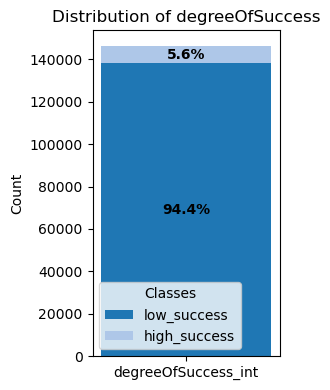

In [9]:
class_names = {0: 'low_success', 1: "high_success"}  # Adatta ai tuoi valori

counts = df["degreeOfSuccess_int"].value_counts().sort_index()
total = counts.sum()  # Totale per calcolare le percentuali

plt.figure(figsize=(3, 4))
colors = plt.cm.tab20.colors

bottom = 0
for i, (cls, count) in enumerate(counts.items()):
    # Calcola la percentuale
    percentage = (count / total) * 100
    
    # Crea la barra
    plt.bar('degreeOfSuccess_int', count, bottom=bottom, 
            label=class_names.get(cls, str(cls)), color=colors[i % len(colors)])
    
    # Aggiungi il testo della percentuale al centro della barra
    text_y = bottom + count / 2  # Posizione verticale al centro della barra
    plt.text(0, text_y, f'{percentage:.1f}%', 
             ha='center', va='center', fontweight='bold', color='black', fontsize=10)
    
    bottom += count

plt.ylabel('Count')
plt.title('Distribution of degreeOfSuccess')
plt.legend(title='Classes')
plt.tight_layout()
plt.show()

### Classification task SENZA agire sullo sbilanciamento

In [10]:
X = df.drop(columns=["degreeOfSuccess_str", "degreeOfSuccess_int", "totalNominations", "originalTitle"], axis=1)
y = df["degreeOfSuccess_int"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [12]:
y_test

122320    0
109016    0
29559     0
15782     0
53292     0
         ..
16083     0
3529      0
74417     0
112380    0
79755     0
Name: degreeOfSuccess_int, Length: 43900, dtype: int64

In [13]:
y_test.value_counts()

degreeOfSuccess_int
0    41394
1     2506
Name: count, dtype: int64

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

# Parametri da testare
param_grid = {
    'criterion': ['gini', 'entropy'],           # Funzione di impurità
    'max_depth': [5, 10, 15, 20],         # Profondità massima dell'albero
    'min_samples_split': [2, 5, 10],            # Minimo campioni per split
    'min_samples_leaf': [1, 2, 4]               # Minimo campioni per foglia
}

# f1_scorer = make_scorer(f1_score, pos_label="high_success")

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=2
)
# Addestramento
grid_search.fit(X_train, y_train)

# Migliori parametri
print("Migliori parametri:", grid_search.best_params_)
print("Migliore f1:", grid_search.best_score_)

# Miglior modello trovato
best_dt = grid_search.best_estimator_

### Valori che emergono dalla gridsearch

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Migliore f1: 0.9421161780318629

In [15]:
clf = DecisionTreeClassifier(criterion="entropy", max_depth=10, min_samples_leaf=4, min_samples_split=10)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=4,
                       min_samples_split=10)

In [16]:
y_pred = clf.predict(X_test)

In [17]:
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

F1-score [0.97347322 0.40278522]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     41394
           1       0.61      0.30      0.40      2506

    accuracy                           0.95     43900
   macro avg       0.79      0.64      0.69     43900
weighted avg       0.94      0.95      0.94     43900



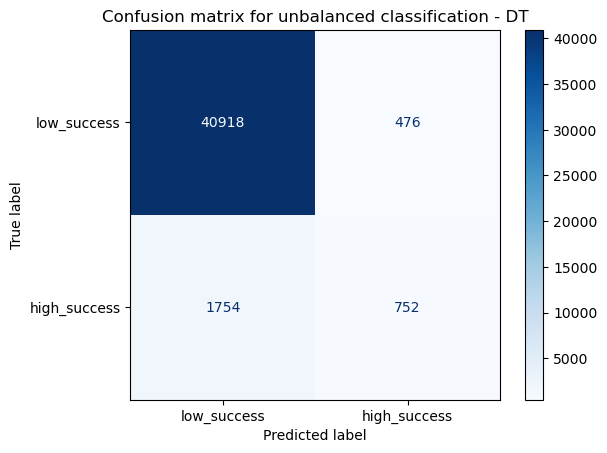

In [18]:
label_mapping = {
    0: "low_success",
    1: "high_success",
}

cm = confusion_matrix(y_test, y_pred)
labels = [label_mapping[i] for i in sorted(label_mapping.keys())]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion matrix for unbalanced classification - DT")
plt.show()

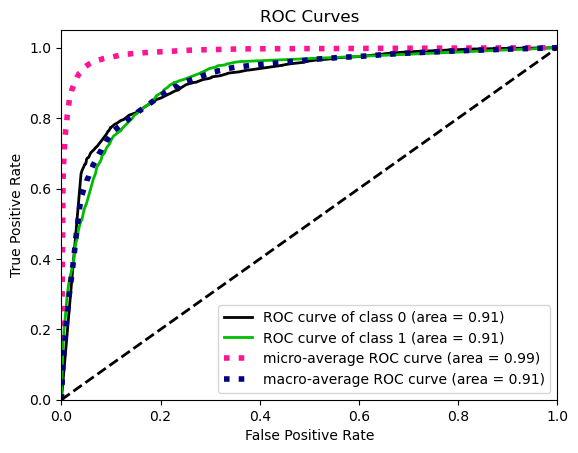

In [19]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

In [20]:
# storing class 1 ROC curve for successive comparisons
y_score = clf.predict_proba(X_test)
fpr0, tpr0, _ = roc_curve(y_test, y_score[:, 1])
roc_auc0 = auc(fpr0, tpr0)

### Assessing the imbalance

In [21]:
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.under_sampling import CondensedNearestNeighbour, TomekLinks
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    precision_recall_curve, average_precision_score
)
from collections import Counter
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline


#### OVERSAMPLING - SMOTE

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, make_scorer, f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Pipeline: SMOTE → DecisionTree
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', DecisionTreeClassifier(random_state=42))
])

# Griglia di iperparametri
param_grid = {
    'smote__k_neighbors': [11, 25, 45],  # Parametri SMOTE
    'clf__criterion': ['gini', 'entropy'],        # Parametri DecisionTree
    'clf__max_depth': [5, 10, 15],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__min_samples_split': [2, 5, 10]
}

# GridSearch con F1 macro
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring=make_scorer(f1_score, average='macro'),
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("\nMigliori parametri trovati:")
print(grid_search.best_params_)
print("\nMiglior F1 macro:", grid_search.best_score_)

# Valutazione sul test set
y_pred = grid_search.predict(X_test)
print("\nClassification Report sul test set:")
print(classification_report(y_test, y_pred))

#### OVERSAMPLING - ADASYN

In [ ]:
print("\n=== ADASYN ===")
pipeline = Pipeline([
    ('adasyn', ADASYN(random_state=42)),
    ('clf', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'adasyn__n_neighbors': [11, 25, 45],
    'clf__criterion': ['gini', 'entropy'],
    'clf__max_depth': [5, 10, 15],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(pipeline, param_grid, scoring=make_scorer(f1_score, average='macro'),
                           cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("\nMigliori parametri trovati:")
print(grid_search.best_params_)
print("\nMiglior F1 macro:", grid_search.best_score_)

y_pred = grid_search.predict(X_test)
print("\nClassification Report sul test set:")
print(classification_report(y_test, y_pred))


#### UNDERSAMPLING - TOMEK LINKS

In [ ]:
print("\n=== Tomek Links ===")
pipeline = Pipeline([
    ('tomek', TomekLinks(n_jobs=-1)),
    ('clf', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'clf__criterion': ['gini', 'entropy'],
    'clf__max_depth': [5, 10, 15],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(pipeline, param_grid, scoring=make_scorer(f1_score, average='macro'),
                           cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("\nMigliori parametri trovati:")
print(grid_search.best_params_)
print("\nMiglior F1 macro:", grid_search.best_score_)

y_pred = grid_search.predict(X_test)
print("\nClassification Report sul test set:")
print(classification_report(y_test, y_pred))


=== Tomek Links ===
Fitting 3 folds for each of 54 candidates, totalling 162 fits

Migliori parametri trovati:
{'clf__criterion': 'gini', 'clf__max_depth': 10, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}

Miglior F1 macro: 0.7045723527865867

Classification Report sul test set:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     41394
           1       0.61      0.33      0.43      2506

    accuracy                           0.95     43900
   macro avg       0.79      0.66      0.70     43900
weighted avg       0.94      0.95      0.94     43900



#### UNDERSAMPLING - ENN

In [ ]:
print("\n=== ENN ===")
pipeline = Pipeline([
    ('enn', EditedNearestNeighbours(n_jobs=-1)),
    ('clf', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'enn__n_neighbors': [3, 7, 9],
    'clf__criterion': ['gini', 'entropy'],
    'clf__max_depth': [5, 10, 15],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(pipeline, param_grid, scoring=make_scorer(f1_score, average='macro'),
                           cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("\nMigliori parametri trovati:")
print(grid_search.best_params_)
print("\nMiglior F1 macro:", grid_search.best_score_)

y_pred = grid_search.predict(X_test)
print("\nClassification Report sul test set:")
print(classification_report(y_test, y_pred))


=== ENN ===
Fitting 3 folds for each of 162 candidates, totalling 486 fits



Migliori parametri trovati:
{'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'enn__n_neighbors': 3}

Miglior F1 macro: 0.7265236860317663

Classification Report sul test set:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     41394
           1       0.49      0.46      0.47      2506

    accuracy                           0.94     43900
   macro avg       0.73      0.72      0.72     43900
weighted avg       0.94      0.94      0.94     43900

